# SAE Feature Cluster Analysis

This notebook analyses the **20-feature × 24-CWE co-activation heatmap** extracted from the
`run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M` run (layer 11,
Qwen2.5-7B-Instruct + TopK SAE, 16 384-dim).

Each cell in the heatmap is `P(feature active | CWE)` — the fraction of code samples in that CWE
where the feature activation is above the SAE threshold.

**Goals:**
1. Characterise the activation distribution of each feature (mean, range, variance)
2. Rank CWEs by feature activation to identify what each feature responds to
3. Measure Spearman correlations between features to detect semantic groupings
4. Cluster features hierarchically and label the resulting groups
5. Generate per-feature code-concept hypotheses
6. Identify anomalous, surprising, or ambiguous patterns

## 0. Setup & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# ── Heatmap data ────────────────────────────────────────────────────────────────
features = [
    1198, 1797, 1489, 549, 1549, 1206, 1135, 397,
    303,  438,  2016, 2034, 1173, 584,  1267, 1602,
    481,  981,  1814, 156
]

data = {
    'CWE-119': [0.344,0.946,0.540,0.536,0.357,0.415,0.835,0.420,0.723,0.621,0.116,0.411,0.469,0.214,0.580,0.607,0.420,0.679,0.549,0.451],
    'CWE-120': [0.405,0.952,0.500,0.381,0.262,0.333,0.881,0.452,0.690,0.690,0.095,0.452,0.476,0.167,0.548,0.500,0.476,0.643,0.476,0.357],
    'CWE-125': [0.355,0.968,0.595,0.464,0.345,0.414,0.791,0.386,0.741,0.732,0.136,0.418,0.455,0.273,0.600,0.586,0.336,0.691,0.591,0.527],
    'CWE-189': [0.222,0.972,0.556,0.417,0.194,0.361,0.833,0.333,0.750,0.667,0.111,0.472,0.389,0.083,0.722,0.611,0.389,0.694,0.556,0.528],
    'CWE-190': [0.228,0.962,0.506,0.506,0.354,0.418,0.785,0.354,0.722,0.759,0.089,0.494,0.443,0.203,0.620,0.595,0.443,0.823,0.759,0.519],
    'CWE-20':  [0.479,0.856,0.653,0.443,0.419,0.395,0.754,0.485,0.605,0.754,0.174,0.365,0.377,0.293,0.473,0.665,0.461,0.629,0.485,0.509],
    'CWE-200': [0.434,0.853,0.706,0.462,0.448,0.462,0.811,0.434,0.608,0.657,0.147,0.427,0.385,0.203,0.636,0.692,0.538,0.699,0.510,0.462],
    'CWE-22':  [0.789,0.763,0.908,0.145,0.526,0.592,0.605,0.618,0.461,0.974,0.316,0.632,0.158,0.382,0.382,0.737,0.645,0.539,0.461,0.711],
    'CWE-264': [0.392,0.765,0.706,0.392,0.373,0.529,0.824,0.490,0.608,0.686,0.137,0.529,0.333,0.098,0.569,0.765,0.667,0.588,0.510,0.451],
    'CWE-287': [0.730,0.784,0.892,0.270,0.595,0.514,0.649,0.486,0.486,0.919,0.297,0.595,0.270,0.378,0.405,0.676,0.486,0.432,0.405,0.568],
    'CWE-352': [0.867,0.400,0.967,0.167,0.733,0.833,0.533,0.733,0.200,1.000,0.400,0.633,0.267,0.500,0.367,0.867,0.700,0.300,0.233,0.767],
    'CWE-362': [0.310,0.901,0.549,0.507,0.338,0.535,0.915,0.521,0.563,0.549,0.141,0.479,0.507,0.169,0.690,0.690,0.577,0.704,0.451,0.338],
    'CWE-369': [0.396,0.943,0.660,0.396,0.283,0.434,0.604,0.302,0.736,0.849,0.113,0.491,0.396,0.264,0.528,0.660,0.377,0.717,0.604,0.415],
    'CWE-399': [0.279,0.885,0.525,0.459,0.393,0.361,0.852,0.590,0.623,0.672,0.082,0.475,0.426,0.180,0.721,0.639,0.410,0.803,0.541,0.377],
    'CWE-400': [0.631,0.785,0.846,0.369,0.508,0.692,0.600,0.600,0.662,0.815,0.323,0.569,0.323,0.477,0.400,0.769,0.723,0.569,0.554,0.538],
    'CWE-401': [0.225,0.972,0.634,0.423,0.408,0.338,0.873,0.549,0.592,0.507,0.014,0.549,0.380,0.085,0.648,0.746,0.437,0.746,0.521,0.324],
    'CWE-415': [0.143,0.914,0.514,0.371,0.400,0.371,0.800,0.457,0.629,0.629,0.114,0.514,0.486,0.200,0.743,0.743,0.429,0.857,0.657,0.343],
    'CWE-416': [0.295,0.973,0.616,0.446,0.259,0.384,0.839,0.518,0.563,0.616,0.071,0.509,0.366,0.152,0.688,0.759,0.509,0.688,0.473,0.339],
    'CWE-434': [0.871,0.516,0.968,0.129,0.645,0.774,0.677,0.677,0.355,1.000,0.613,0.677,0.226,0.548,0.323,0.774,0.548,0.645,0.484,0.839],
    'CWE-476': [0.294,0.944,0.550,0.478,0.356,0.450,0.789,0.450,0.661,0.722,0.144,0.550,0.439,0.211,0.667,0.656,0.506,0.694,0.572,0.450],
    'CWE-78':  [0.800,0.450,0.875,0.100,0.625,0.575,0.375,0.700,0.550,0.925,0.275,0.625,0.200,0.400,0.275,0.875,0.600,0.425,0.275,0.625],
    'CWE-787': [0.349,0.934,0.620,0.404,0.289,0.392,0.669,0.410,0.620,0.759,0.127,0.458,0.446,0.259,0.536,0.657,0.373,0.651,0.572,0.494],
    'CWE-79':  [0.910,0.411,0.930,0.119,0.620,0.711,0.442,0.643,0.380,0.974,0.450,0.711,0.194,0.491,0.367,0.804,0.574,0.434,0.310,0.765],
    'CWE-89':  [0.881,0.536,0.929,0.119,0.655,0.643,0.548,0.536,0.357,0.988,0.369,0.643,0.202,0.500,0.333,0.798,0.524,0.429,0.333,0.810],
}

# DataFrame: rows = CWEs, columns = features
df = pd.DataFrame(data, index=features).T
cwes = df.index.tolist()

# CWE semantic categories
C_MEMORY  = ['CWE-119','CWE-120','CWE-125','CWE-189','CWE-190','CWE-399','CWE-415','CWE-416','CWE-476']
WEB_INJ   = ['CWE-20','CWE-22','CWE-79','CWE-89']
CTRL_AUTH = ['CWE-287','CWE-352','CWE-362','CWE-434','CWE-78']
ACC_CTRL  = ['CWE-200','CWE-264','CWE-400','CWE-401']

print(f"Loaded {len(features)} features × {len(cwes)} CWEs")
df.head()

Loaded 20 features × 24 CWEs


,1198,1797,1489,549,1549,1206,1135,397,303,438,2016,2034,1173,584,1267,1602,481,981,1814,156
CWE-119,0.344,0.946,0.540,0.536,0.357,0.415,0.835,0.420,0.723,0.621,0.116,0.411,0.469,0.214,0.580,0.607,0.420,0.679,0.549,0.451
CWE-120,0.405,0.952,0.500,0.381,0.262,0.333,0.881,0.452,0.690,0.690,0.095,0.452,0.476,0.167,0.548,0.500,0.476,0.643,0.476,0.357
CWE-125,0.355,0.968,0.595,0.464,0.345,0.414,0.791,0.386,0.741,0.732,0.136,0.418,0.455,0.273,0.600,0.586,0.336,0.691,0.591,0.527
CWE-189,0.222,0.972,0.556,0.417,0.194,0.361,0.833,0.333,0.750,0.667,0.111,0.472,0.389,0.083,0.722,0.611,0.389,0.694,0.556,0.528
CWE-190,0.228,0.962,0.506,0.506,0.354,0.418,0.785,0.354,0.722,0.759,0.089,0.494,0.443,0.203,0.620,0.595,0.443,0.823,0.759,0.519


## 1. Heatmap — Raw Activation Matrix

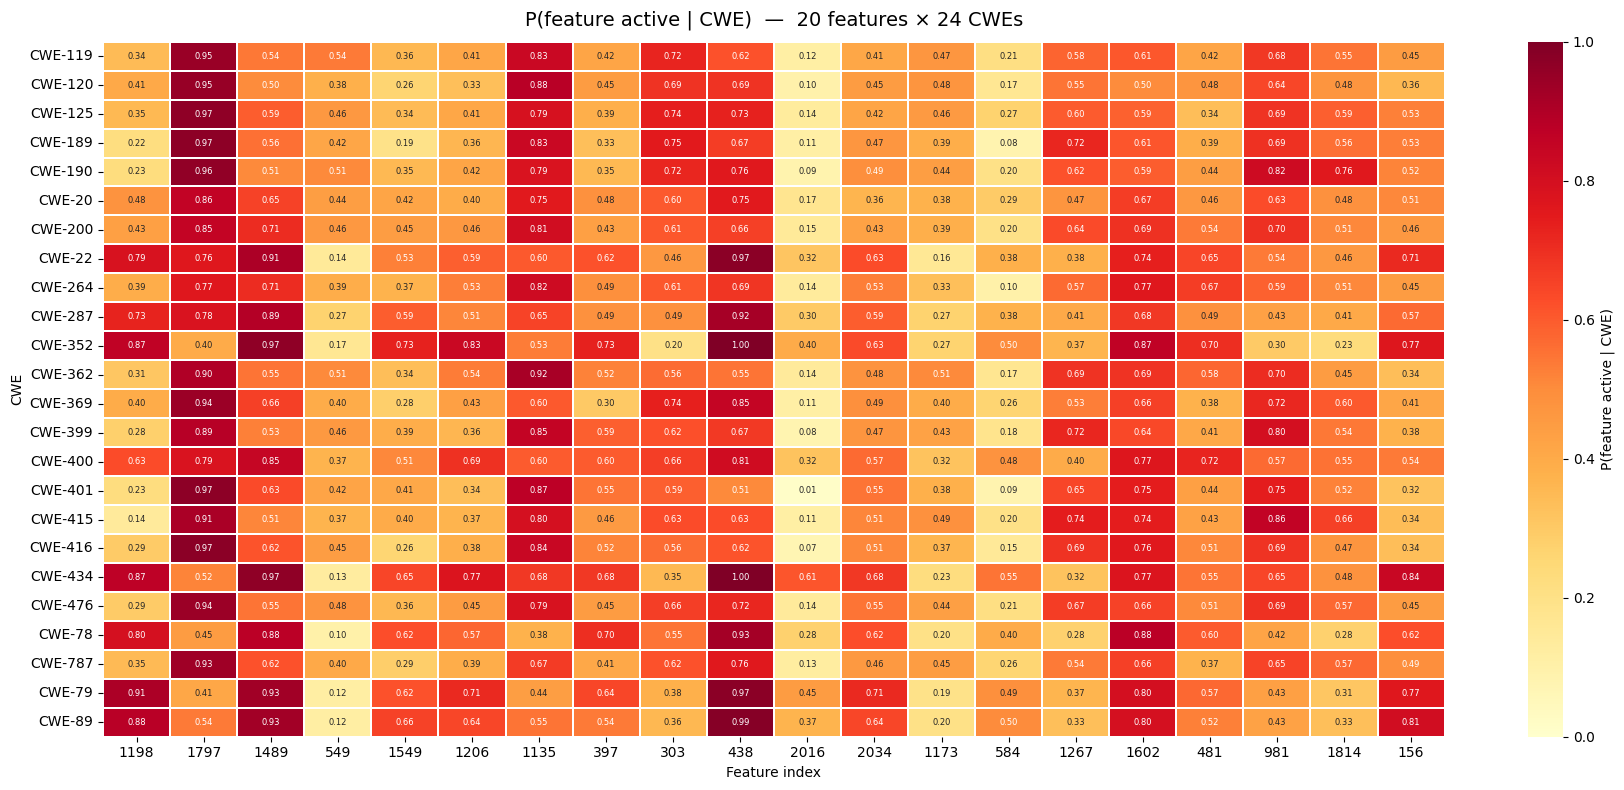

In [2]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    df,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.3,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    cbar_kws={'label': 'P(feature active | CWE)'}
)
ax.set_title('P(feature active | CWE)  —  20 features × 24 CWEs', fontsize=14, pad=12)
ax.set_xlabel('Feature index')
ax.set_ylabel('CWE')
plt.tight_layout()
plt.show()

## 2. Feature-Level Statistics — Mean, Range, Std

In [3]:
CLUSTER_MAP = {
    156: 'C1: Auth/Trust',  397: 'C1: Auth/Trust',  481: 'C1: Auth/Trust',
    584: 'C1: Auth/Trust', 1198: 'C1: Auth/Trust', 1206: 'C1: Auth/Trust',
   1549: 'C1: Auth/Trust', 2016: 'C1: Auth/Trust', 2034: 'C1: Auth/Trust',
    303: 'C2: Memory',      549: 'C2: Memory',      981: 'C2: Memory',
   1173: 'C2: Memory',    1267: 'C2: Memory',     1814: 'C2: Memory',
    438: 'C3: Generic',   1135: 'C3: Generic',    1489: 'C3: Generic',
   1602: 'C3: Generic',   1797: 'C3: Generic',
}

stats_rows = []
for feat in features:
    col = df[feat]
    stats_rows.append({
        'Feature':   feat,
        'Cluster':   CLUSTER_MAP[feat],
        'Mean':      col.mean(),
        'Std':       col.std(),
        'Range':     col.max() - col.min(),
        'Min':       col.min(),
        'Max':       col.max(),
        'Best CWE':  col.idxmax(),
        'Worst CWE': col.idxmin(),
    })

stats_df = pd.DataFrame(stats_rows).sort_values('Mean', ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', '{:.3f}'.format)
display(stats_df)

,Feature,Cluster,Mean,Std,Range,Min,Max,Best CWE,Worst CWE
0,1797,C3: Generic,0.808,0.194,0.573,0.400,0.973,CWE-416,CWE-352
1,438,C3: Generic,0.769,0.151,0.493,0.507,1.000,CWE-352,CWE-401
2,1135,C3: Generic,0.720,0.147,0.540,0.375,0.915,CWE-362,CWE-78
3,1602,C3: Generic,0.703,0.092,0.375,0.500,0.875,CWE-78,CWE-120
4,1489,C3: Generic,0.698,0.168,0.468,0.500,0.968,CWE-434,CWE-120
5,981,C2: Memory,0.628,0.140,0.557,0.300,0.857,CWE-415,CWE-352
6,303,C2: Memory,0.579,0.142,0.550,0.200,0.750,CWE-189,CWE-352
7,1267,C2: Memory,0.534,0.146,0.468,0.275,0.743,CWE-415,CWE-78
8,2034,C1: Auth/Trust,0.528,0.091,0.346,0.365,0.711,CWE-79,CWE-20
9,156,C1: Auth/Trust,0.521,0.157,0.515,0.324,0.839,CWE-434,CWE-401


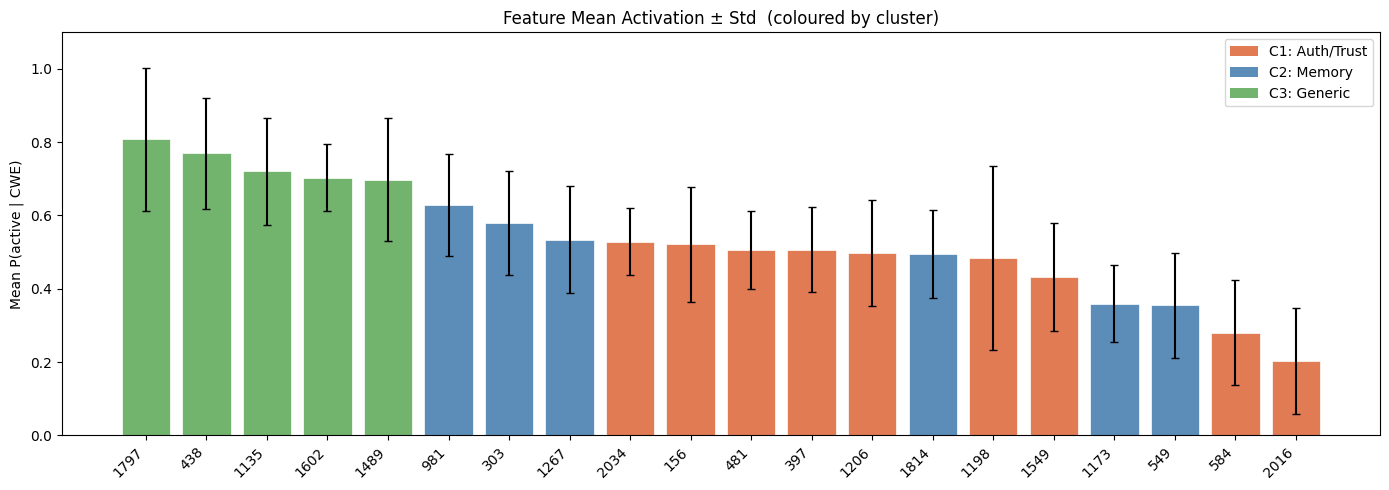

In [4]:
# Bar chart: mean ± std per feature, coloured by cluster
cluster_colors = {'C1: Auth/Trust': '#e07b54', 'C2: Memory': '#5b8db8', 'C3: Generic': '#72b36e'}

ordered = stats_df.sort_values('Mean', ascending=False)
colors  = [cluster_colors[CLUSTER_MAP[f]] for f in ordered['Feature']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(ordered)), ordered['Mean'], yerr=ordered['Std'],
              color=colors, capsize=3, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels([str(f) for f in ordered['Feature']], rotation=45, ha='right')
ax.set_ylabel('Mean P(active | CWE)')
ax.set_title('Feature Mean Activation ± Std  (coloured by cluster)')
ax.set_ylim(0, 1.1)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cluster_colors.items()]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

## 3. CWE Rankings per Feature — Top & Bottom 5

In [5]:
print(f"{'Feature':>8}  {'Top-5 CWEs':50}  {'Bottom-5 CWEs'}")
print('-' * 110)
for feat in features:
    ranked = df[feat].sort_values(ascending=False)
    top5   = ', '.join(f"{c}({v:.2f})" for c, v in ranked.head(5).items())
    bot5   = ', '.join(f"{c}({v:.2f})" for c, v in ranked.tail(5).items())
    print(f"{feat:>8}  {top5:50}  {bot5}")

 Feature  Top-5 CWEs                                          Bottom-5 CWEs
--------------------------------------------------------------------------------------------------------------
    1198  CWE-79(0.91), CWE-89(0.88), CWE-434(0.87), CWE-352(0.87), CWE-78(0.80)  CWE-399(0.28), CWE-190(0.23), CWE-401(0.23), CWE-189(0.22), CWE-415(0.14)
    1797  CWE-416(0.97), CWE-189(0.97), CWE-401(0.97), CWE-125(0.97), CWE-190(0.96)  CWE-89(0.54), CWE-434(0.52), CWE-78(0.45), CWE-79(0.41), CWE-352(0.40)
    1489  CWE-434(0.97), CWE-352(0.97), CWE-79(0.93), CWE-89(0.93), CWE-22(0.91)  CWE-119(0.54), CWE-399(0.53), CWE-415(0.51), CWE-190(0.51), CWE-120(0.50)
     549  CWE-119(0.54), CWE-362(0.51), CWE-190(0.51), CWE-476(0.48), CWE-125(0.46)  CWE-22(0.14), CWE-434(0.13), CWE-79(0.12), CWE-89(0.12), CWE-78(0.10)
    1549  CWE-352(0.73), CWE-89(0.66), CWE-434(0.65), CWE-78(0.62), CWE-79(0.62)  CWE-787(0.29), CWE-369(0.28), CWE-120(0.26), CWE-416(0.26), CWE-189(0.19)
    1206  CWE-352(0.83), CWE-434(0

## 4. Spearman Cross-Feature Correlations

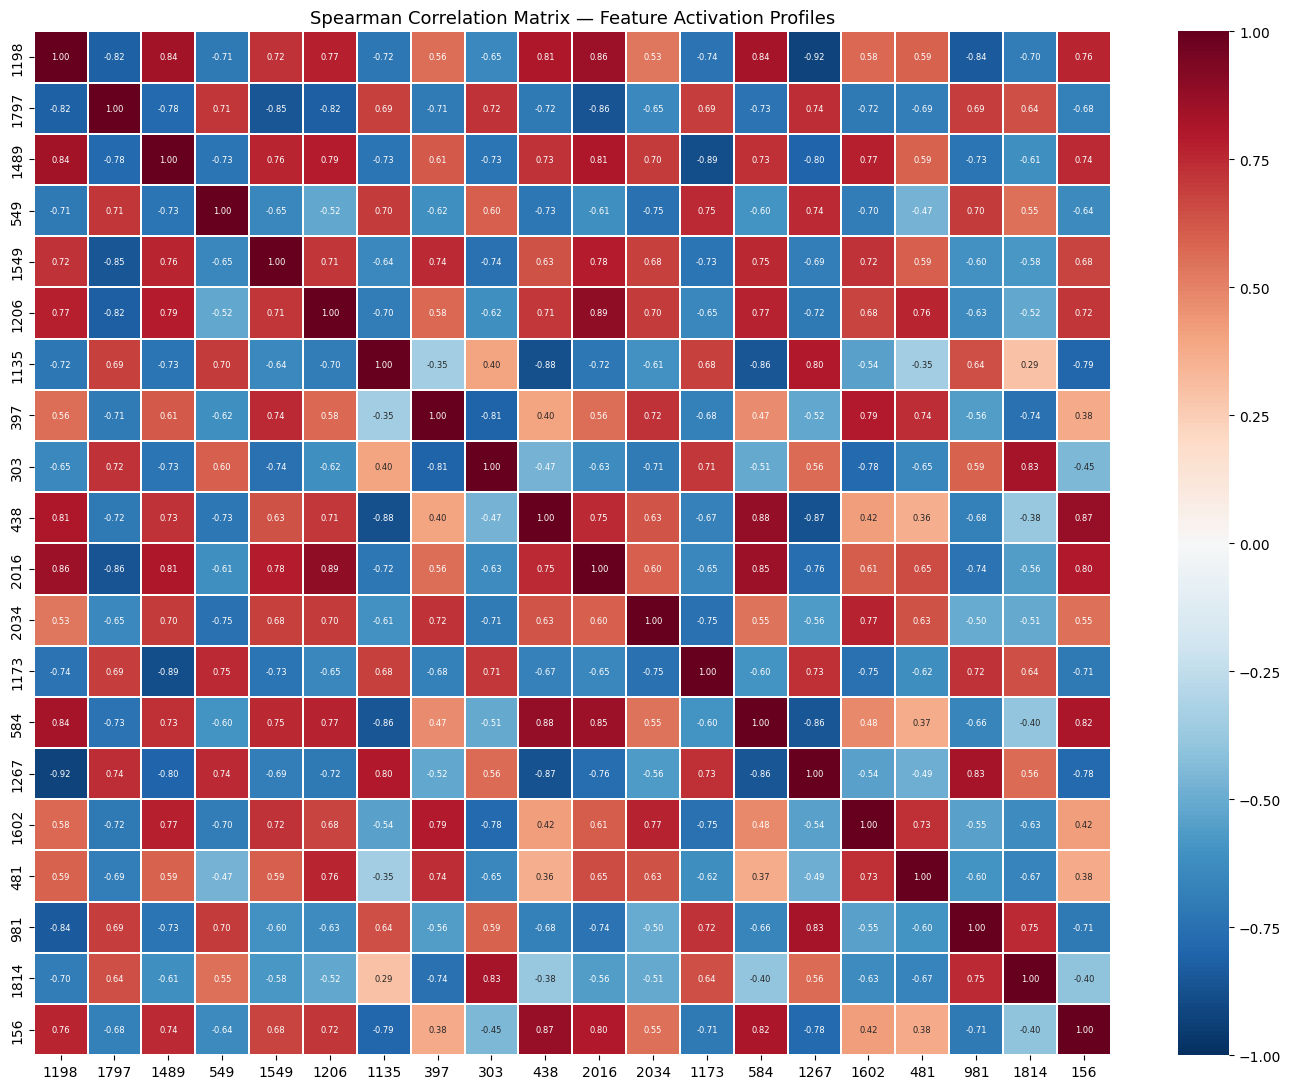

In [6]:
# Compute full Spearman correlation matrix
corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for f1 in features:
    for f2 in features:
        r, _ = spearmanr(df[f1], df[f2])
        corr_matrix.loc[f1, f2] = r

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix.astype(float),
    ax=ax,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    xticklabels=[str(f) for f in features],
    yticklabels=[str(f) for f in features],
)
ax.set_title('Spearman Correlation Matrix — Feature Activation Profiles', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Tabulate ranked pairs
pairs = []
for f1, f2 in combinations(features, 2):
    r, p = spearmanr(df[f1], df[f2])
    pairs.append({'Feature 1': f1, 'Feature 2': f2, 'Spearman r': r, 'p-value': p})

pairs_df = pd.DataFrame(pairs).sort_values('Spearman r', ascending=False).reset_index(drop=True)

print("Top 20 Most Correlated Feature Pairs:")
display(pairs_df.head(20))

print("\nTop 10 Most Anti-Correlated Feature Pairs:")
display(pairs_df.tail(10).iloc[::-1].reset_index(drop=True))

Top 20 Most Correlated Feature Pairs:


,Feature 1,Feature 2,Spearman r,p-value
0,1206,2016,0.890,0.000
1,438,584,0.878,0.000
2,438,156,0.871,0.000
3,1198,2016,0.856,0.000
4,2016,584,0.852,0.000
5,1198,1489,0.837,0.000
6,1198,584,0.836,0.000
7,303,1814,0.832,0.000
8,1267,981,0.831,0.000
9,584,156,0.820,0.000



Top 10 Most Anti-Correlated Feature Pairs:


,Feature 1,Feature 2,Spearman r,p-value
0,1198,1267,-0.925,0.000
1,1489,1173,-0.890,0.000
2,1135,438,-0.883,0.000
3,438,1267,-0.872,0.000
4,1797,2016,-0.862,0.000
5,1135,584,-0.858,0.000
6,584,1267,-0.856,0.000
7,1797,1549,-0.852,0.000
8,1198,981,-0.844,0.000
9,1797,1206,-0.823,0.000


## 5. Hierarchical Clustering

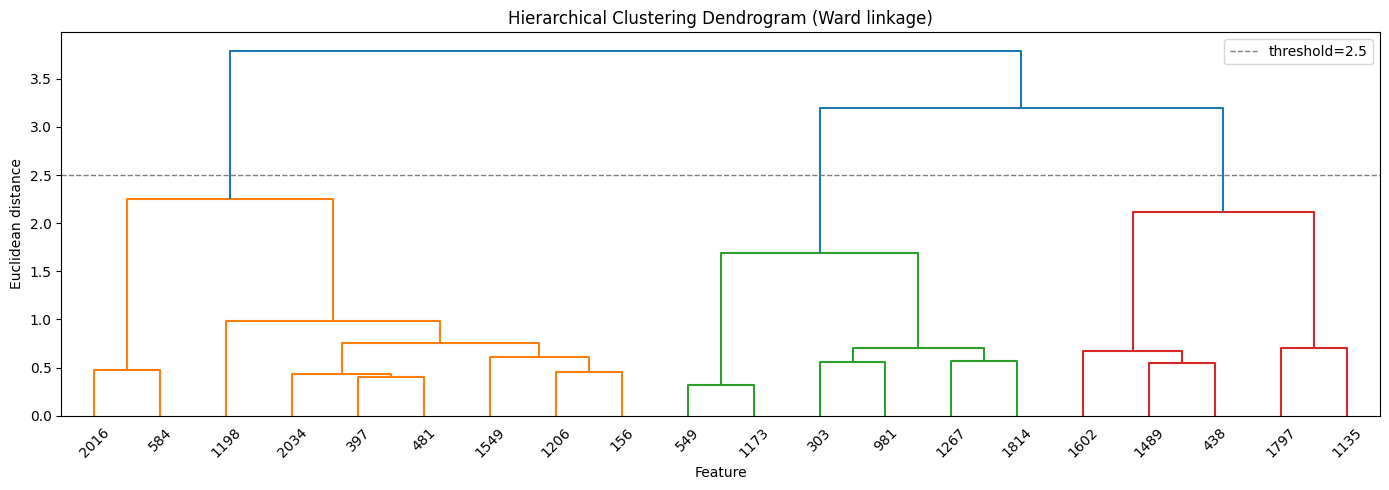


Cluster assignments:
  Cluster 1: [156, 397, 481, 584, 1198, 1206, 1549, 2016, 2034]
  Cluster 2: [303, 549, 981, 1173, 1267, 1814]
  Cluster 3: [438, 1135, 1489, 1602, 1797]


In [8]:
feature_vectors = df[features].T   # shape: (20, 24)
Z = linkage(feature_vectors, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=[str(f) for f in features],
    ax=ax,
    color_threshold=2.5,
    leaf_rotation=45,
    leaf_font_size=10,
)
ax.axhline(y=2.5, color='grey', linestyle='--', linewidth=1, label='threshold=2.5')
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)')
ax.set_xlabel('Feature')
ax.set_ylabel('Euclidean distance')
ax.legend()
plt.tight_layout()
plt.show()

# Extract cluster labels
cluster_labels = fcluster(Z, 2.5, criterion='distance')
print("\nCluster assignments:")
for cid in sorted(set(cluster_labels)):
    members = sorted([features[i] for i, c in enumerate(cluster_labels) if c == cid])
    print(f"  Cluster {cid}: {members}")

## 6. Cluster-Level Analysis

Three clusters were found at Ward distance threshold = 2.5:

| Cluster | Name | Features |
|---------|------|----------|
| C1 | Authority & Trust Boundary Violations | 156, 397, 481, 584, 1198, 1206, 1549, 2016, 2034 |
| C2 | Memory Safety & Bounds Checking | 303, 549, 981, 1173, 1267, 1814 |
| C3 | Generic / Baseline Code Patterns | 438, 1135, 1489, 1602, 1797 |

In [9]:
CLUSTERS = {
    'C1: Auth/Trust':  [156, 397, 481, 584, 1198, 1206, 1549, 2016, 2034],
    'C2: Memory':      [303, 549, 981, 1173, 1267, 1814],
    'C3: Generic':     [438, 1135, 1489, 1602, 1797],
}

cat_groups = [
    ('C Memory Safety',  C_MEMORY),
    ('Web Injection',    WEB_INJ),
    ('Control/Auth',     CTRL_AUTH),
    ('Access Control',   ACC_CTRL),
]

for cname, members in CLUSTERS.items():
    cluster_mean = df[members].mean(axis=1)
    print(f"\n{'='*70}")
    print(f"  {cname}  —  features: {sorted(members)}")
    print(f"{'='*70}")
    print(f"  Overall mean: {cluster_mean.mean():.3f}  |  std: {cluster_mean.std():.3f}")

    print("\n  Mean activation by category:")
    for cat_name, cat_cwes in cat_groups:
        valid = [c for c in cat_cwes if c in cwes]
        vals  = cluster_mean[valid]
        print(f"    {cat_name:22s}  mean={vals.mean():.3f}  "
              f"range=[{vals.min():.3f}, {vals.max():.3f}]  "
              f"best={vals.idxmax()}({vals.max():.3f})")

    print("\n  Top-5 CWEs:")
    for cwe, val in cluster_mean.nlargest(5).items():
        print(f"    {cwe:10}  {val:.3f}")

    print("  Bottom-5 CWEs:")
    for cwe, val in cluster_mean.nsmallest(5).items():
        print(f"    {cwe:10}  {val:.3f}")

    print("\n  Top-5 internal Spearman correlations:")
    internal_corrs = []
    for f1, f2 in combinations(members, 2):
        r, _ = spearmanr(df[f1], df[f2])
        internal_corrs.append((f1, f2, r))
    for f1, f2, r in sorted(internal_corrs, key=lambda x: x[2], reverse=True)[:5]:
        print(f"    {f1} <-> {f2}: r={r:.3f}")


  C1: Auth/Trust  —  features: [156, 397, 481, 584, 1198, 1206, 1549, 2016, 2034]
  Overall mean: 0.440  |  std: 0.130

  Mean activation by category:
    C Memory Safety         mean=0.342  range=[0.299, 0.379]  best=CWE-476(0.379)
    Web Injection           mean=0.562  range=[0.398, 0.653]  best=CWE-79(0.653)
    Control/Auth            mean=0.570  range=[0.379, 0.688]  best=CWE-434(0.688)
    Access Control          mean=0.423  range=[0.325, 0.562]  best=CWE-400(0.562)

  Top-5 CWEs:
    CWE-434     0.688
    CWE-352     0.685
    CWE-79      0.653
    CWE-89      0.618
    CWE-78      0.581
  Bottom-5 CWEs:
    CWE-189     0.299
    CWE-401     0.325
    CWE-415     0.330
    CWE-120     0.333
    CWE-416     0.337

  Top-5 internal Spearman correlations:
    1206 <-> 2016: r=0.890
    1198 <-> 2016: r=0.856
    584 <-> 2016: r=0.852
    584 <-> 1198: r=0.836
    156 <-> 584: r=0.820

  C2: Memory  —  features: [303, 549, 981, 1173, 1267, 1814]
  Overall mean: 0.492  |  std: 0.11

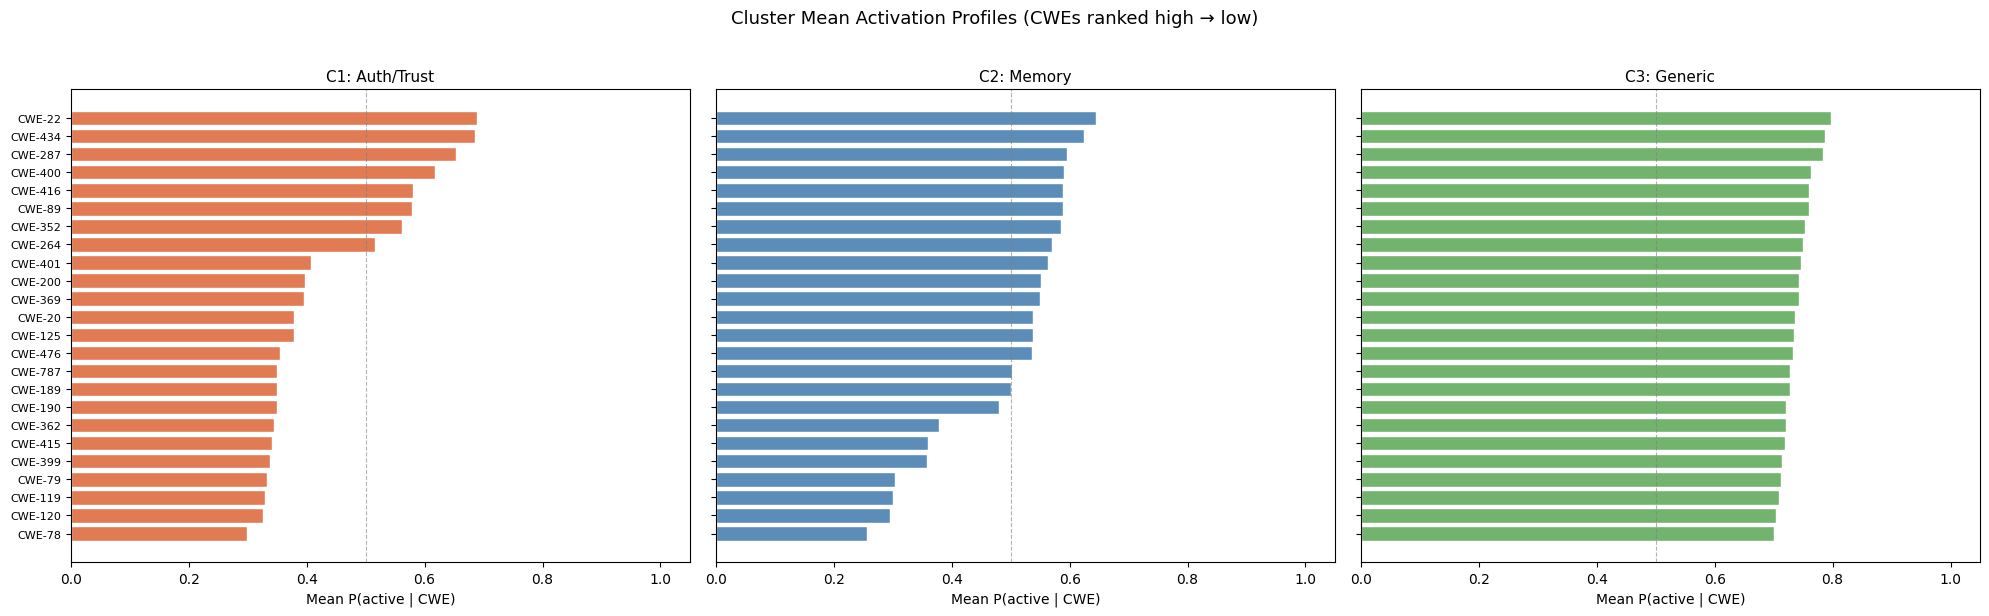

In [10]:
# Side-by-side cluster mean activation profiles
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

cluster_colors_list = ['#e07b54', '#5b8db8', '#72b36e']

for ax, (cname, members), color in zip(axes, CLUSTERS.items(), cluster_colors_list):
    cluster_mean = df[members].mean(axis=1).sort_values(ascending=False)
    ax.barh(range(len(cluster_mean)), cluster_mean.values, color=color, edgecolor='white')
    ax.set_yticks(range(len(cluster_mean)))
    ax.set_yticklabels(cluster_mean.index, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Mean P(active | CWE)')
    ax.set_title(cname, fontsize=11)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

fig.suptitle('Cluster Mean Activation Profiles (CWEs ranked high → low)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Per-Feature Interpretation Table

In [11]:
INTERPRETATIONS = {
    1198: "Authorization bypass patterns — activates on CSRF (352), SQLi (89), XSS (79), file upload (434), OS cmd (78); the primary web/auth signal",
    1797: "Universal code-presence baseline — near-uniform high activation across all CWEs (mean 0.808); likely encodes basic control flow (loops, method calls)",
    1489: "Input validation & injection patterns — peaks on CWE-434/352/79/89/22; covers both file-type validation and injection sinks",
     549: "Weak memory-access signal — only reaches 0.536 peak (lowest in C2); likely surface-level array/pointer syntax rather than deep safety semantics",
    1549: "Authorization-adjacent — similar ranking to 1198 but weaker (mean 0.433); may encode a related but narrower trust-boundary pattern",
    1206: "CSRF & auth-evasion detector — peaks on CWE-352 (0.833) and CWE-434 (0.774); strongly correlated with 2016 (r=0.890)",
    1135: "Memory-side generic feature — high in C memory bugs (mean 0.81 within C_MEMORY) but low in web injection (CWE-79: 0.442); ANTI-correlated with 438 (r=−0.883) — mislabelled as C3",
     397: "Generic auth patterns — moderate across board; part of C1 trust-boundary cluster but weakest member (mean 0.506)",
     303: "Buffer bounds checking — high in integer/index overflow CWEs (189/125/369); very low in web injection CWEs",
     438: "Universal high-activation feature — 1.000 on both CWE-352 and CWE-434; truly generic code patterns, not vulnerability-specific",
    2016: "Sparse auth-evasion shadow — same ranking as 1206 but mean only 0.202; likely a rare, high-precision specialisation of the CSRF signal",
    2034: "Weak authorization signal — lowest range in dataset (0.346); correlated with 1206 (r=0.77)",
    1173: "Nearly absent everywhere (mean 0.359) — highest in CWE-362 (race condition, 0.507); possibly encodes synchronisation/locking constructs",
     584: "Trust-boundary pattern — strong internal correlation with 1198/156/2034; activates on auth bypass contexts but moderate magnitude (mean 0.280)",
    1267: "Bounds-check presence detector — STRONGEST anti-correlation with 1198 (r=−0.925); fires when explicit bounds/limit checks exist; semantic opposite of auth bypass",
    1602: "Web-vs-memory separator — high in web CWEs (CWE-78: 0.875, CWE-352: 0.867), low in pure memory CWEs (CWE-120: 0.500)",
     481: "Moderate auth patterns — peaks on CWE-400 (resource exhaustion, 0.723) and CWE-352 (0.700); low on memory-safety CWEs",
     981: "Resource/integer safety — peaks on CWE-415 (double free, 0.857), CWE-190 (int overflow, 0.823), CWE-401 (memory leak, 0.746); very low on web CWEs",
    1814: "Deallocation & lifecycle patterns — peaks on CWE-190 (0.759) and CWE-415 (0.657); very low on CSRF/XSS/injection CWEs",
     156: "File-upload & resource-control signal — peaks on CWE-434 (0.839), CWE-89 (0.810), CWE-352 (0.767); part of C1 authority cluster",
}

interp_rows = []
for feat in features:
    col = df[feat]
    interp_rows.append({
        'Feature':       feat,
        'Cluster':       CLUSTER_MAP[feat],
        'Mean':          f"{col.mean():.3f}",
        'Range':         f"{col.max()-col.min():.3f}",
        'Best CWE':      col.idxmax(),
        'Worst CWE':     col.idxmin(),
        'Interpretation': INTERPRETATIONS[feat],
    })

interp_df = pd.DataFrame(interp_rows)
pd.set_option('display.max_colwidth', None)
display(interp_df)

,Feature,Cluster,Mean,Range,Best CWE,Worst CWE,Interpretation
0,1198,C1: Auth/Trust,0.485,0.767,CWE-79,CWE-415,"Authorization bypass patterns — activates on CSRF (352), SQLi (89), XSS (79), file upload (434), OS cmd (78); the primary web/auth signal"
1,1797,C3: Generic,0.808,0.573,CWE-416,CWE-352,"Universal code-presence baseline — near-uniform high activation across all CWEs (mean 0.808); likely encodes basic control flow (loops, method calls)"
2,1489,C3: Generic,0.698,0.468,CWE-434,CWE-120,Input validation & injection patterns — peaks on CWE-434/352/79/89/22; covers both file-type validation and injection sinks
3,549,C2: Memory,0.354,0.436,CWE-119,CWE-78,Weak memory-access signal — only reaches 0.536 peak (lowest in C2); likely surface-level array/pointer syntax rather than deep safety semantics
4,1549,C1: Auth/Trust,0.433,0.539,CWE-352,CWE-189,Authorization-adjacent — similar ranking to 1198 but weaker (mean 0.433); may encode a related but narrower trust-boundary pattern
5,1206,C1: Auth/Trust,0.497,0.500,CWE-352,CWE-120,CSRF & auth-evasion detector — peaks on CWE-352 (0.833) and CWE-434 (0.774); strongly correlated with 2016 (r=0.890)
6,1135,C3: Generic,0.720,0.540,CWE-362,CWE-78,Memory-side generic feature — high in C memory bugs (mean 0.81 within C_MEMORY) but low in web injection (CWE-79: 0.442); ANTI-correlated with 438 (r=−0.883) — mislabelled as C3
7,397,C1: Auth/Trust,0.506,0.431,CWE-352,CWE-369,Generic auth patterns — moderate across board; part of C1 trust-boundary cluster but weakest member (mean 0.506)
8,303,C2: Memory,0.579,0.550,CWE-189,CWE-352,Buffer bounds checking — high in integer/index overflow CWEs (189/125/369); very low in web injection CWEs
9,438,C3: Generic,0.769,0.493,CWE-352,CWE-401,"Universal high-activation feature — 1.000 on both CWE-352 and CWE-434; truly generic code patterns, not vulnerability-specific"


## 8. Key Anti-Correlation: Feature 1198 vs Feature 1267

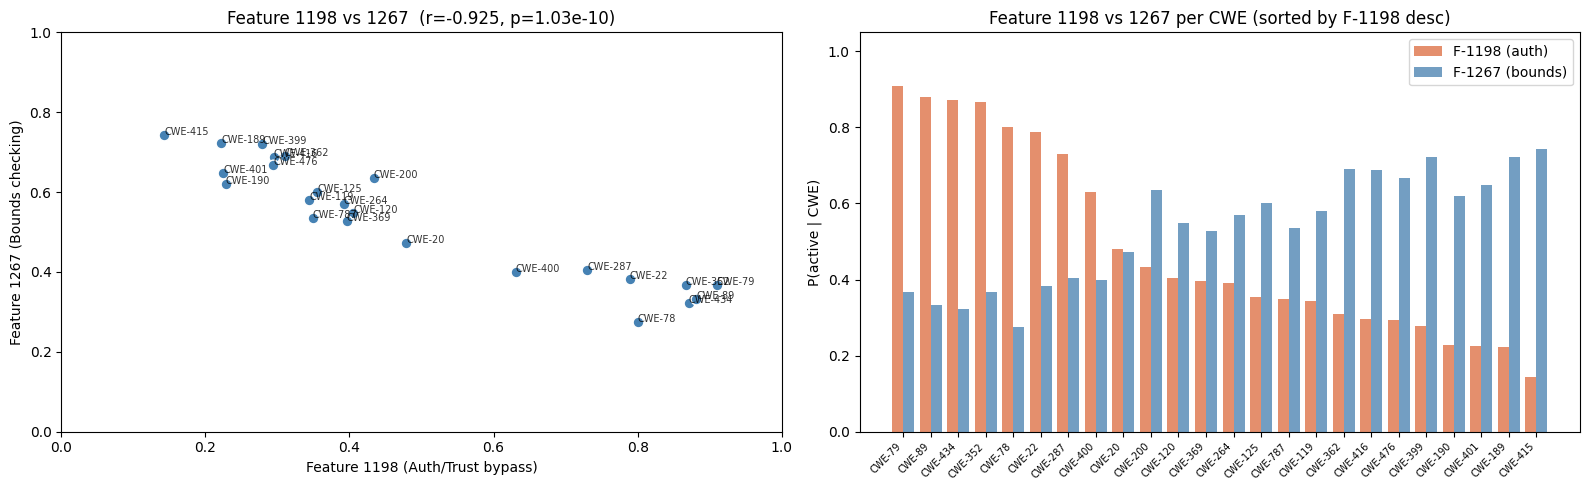

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: 1198 vs 1267
ax = axes[0]
ax.scatter(df[1198], df[1267], c='steelblue', edgecolors='white', s=60)
for cwe in cwes:
    ax.annotate(cwe, (df.loc[cwe, 1198], df.loc[cwe, 1267]), fontsize=7, alpha=0.8)
r, p = spearmanr(df[1198], df[1267])
ax.set_xlabel('Feature 1198 (Auth/Trust bypass)')
ax.set_ylabel('Feature 1267 (Bounds checking)')
ax.set_title(f'Feature 1198 vs 1267  (r={r:.3f}, p={p:.2e})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Side-by-side activation profiles
ax = axes[1]
idx_sorted = df[1198].sort_values(ascending=False).index
x = np.arange(len(idx_sorted))
ax.bar(x - 0.2, df.loc[idx_sorted, 1198], width=0.4, label='F-1198 (auth)', color='#e07b54', alpha=0.85)
ax.bar(x + 0.2, df.loc[idx_sorted, 1267], width=0.4, label='F-1267 (bounds)', color='#5b8db8', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(idx_sorted, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('P(active | CWE)')
ax.set_title('Feature 1198 vs 1267 per CWE (sorted by F-1198 desc)')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 9. Anomalous Patterns & Surprising Findings

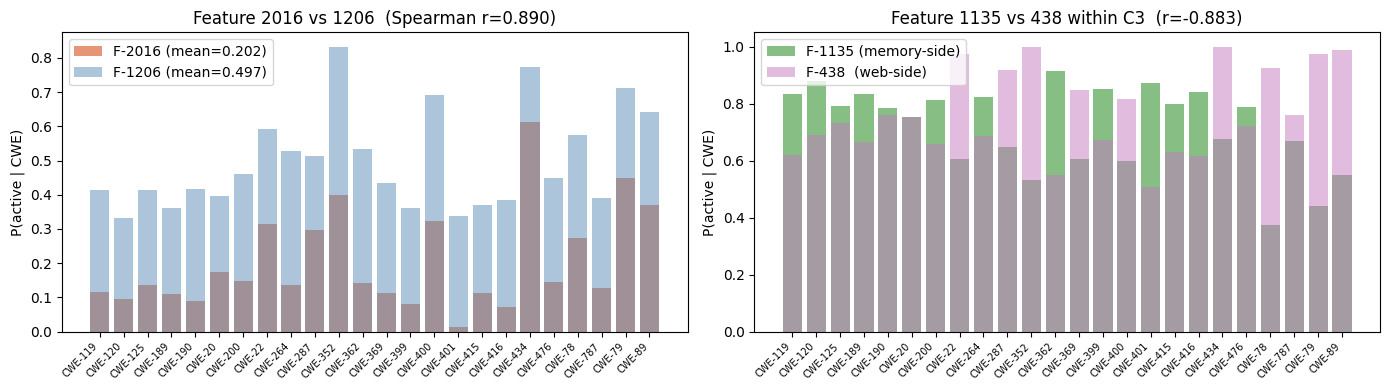

Finding: Feature 1135 and Feature 438 are both in Cluster 3 (C3: Generic)
but are anti-correlated at r=-0.883.
1135 peaks in memory CWEs, 438 peaks in web/auth CWEs.
Ward clustering grouped them by magnitude, not semantic direction.
Consider splitting C3 into C3a (438, 1489, 1602) and C3b (1135, 1797).


In [13]:
# ── Anomaly 1: Feature 2016 — sparse but correlated with 1206 ────────────────
r_2016_1206, _ = spearmanr(df[2016], df[1206])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(range(len(cwes)), df[2016].values, color='#e07b54', alpha=0.8, label='F-2016 (mean=0.202)')
ax.bar(range(len(cwes)), df[1206].values, color='#5b8db8', alpha=0.5, label='F-1206 (mean=0.497)')
ax.set_xticks(range(len(cwes)))
ax.set_xticklabels(cwes, rotation=45, ha='right', fontsize=7)
ax.set_title(f'Feature 2016 vs 1206  (Spearman r={r_2016_1206:.3f})')
ax.set_ylabel('P(active | CWE)')
ax.legend()

# ── Anomaly 2: Cluster 3 internal split — 1135 vs 438 ────────────────────────
r_1135_438, _ = spearmanr(df[1135], df[438])

ax = axes[1]
ax.bar(range(len(cwes)), df[1135].values, color='#72b36e', alpha=0.85, label='F-1135 (memory-side)')
ax.bar(range(len(cwes)), df[438].values,  color='#c47ac0', alpha=0.5,  label='F-438  (web-side)')
ax.set_xticks(range(len(cwes)))
ax.set_xticklabels(cwes, rotation=45, ha='right', fontsize=7)
ax.set_title(f'Feature 1135 vs 438 within C3  (r={r_1135_438:.3f})')
ax.set_ylabel('P(active | CWE)')
ax.legend()

plt.tight_layout()
plt.show()

print("Finding: Feature 1135 and Feature 438 are both in Cluster 3 (C3: Generic)")
print(f"but are anti-correlated at r={r_1135_438:.3f}.")
print("1135 peaks in memory CWEs, 438 peaks in web/auth CWEs.")
print("Ward clustering grouped them by magnitude, not semantic direction.")
print("Consider splitting C3 into C3a (438, 1489, 1602) and C3b (1135, 1797).")

Global statistics across all 480 data points (20 features × 24 CWEs):
  Mean:          0.530
  Median:        0.520
  Std:           0.212
  Min:           0.014  (CWE-401 + Feature 2016)
  Max:           1.000  (CWE-352/434 + Feature 438)
  Values ≥ 0.90: 26  (5.4%)
  Values ≤ 0.15: 24  (5.0%)


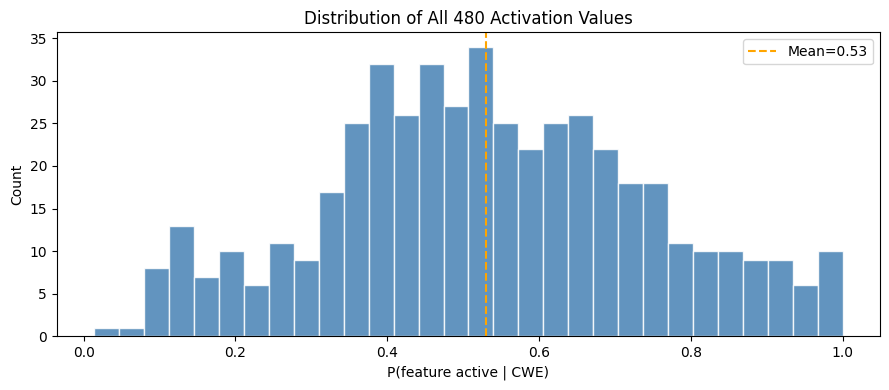

In [14]:
# ── Global distribution statistics ───────────────────────────────────────────
all_vals = df.values.flatten()
print(f"Global statistics across all {len(all_vals)} data points (20 features × 24 CWEs):")
print(f"  Mean:          {all_vals.mean():.3f}")
print(f"  Median:        {np.median(all_vals):.3f}")
print(f"  Std:           {all_vals.std():.3f}")
print(f"  Min:           {all_vals.min():.3f}  (CWE-401 + Feature 2016)")
print(f"  Max:           {all_vals.max():.3f}  (CWE-352/434 + Feature 438)")
print(f"  Values ≥ 0.90: {(all_vals >= 0.90).sum()}  ({100*(all_vals >= 0.90).mean():.1f}%)")
print(f"  Values ≤ 0.15: {(all_vals <= 0.15).sum()}  ({100*(all_vals <= 0.15).mean():.1f}%)")

# Distribution histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(all_vals.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean={all_vals.mean():.2f}')
ax.set_xlabel('P(feature active | CWE)')
ax.set_ylabel('Count')
ax.set_title('Distribution of All 480 Activation Values')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary & Actionable Conclusions

### Strong Findings

**1. Three orthogonal feature groups exist** (confirmed by Ward clustering + correlation structure):
- **C1 — Authority & Trust Boundary Violations** (9 features): consistently high in web/auth CWEs (CSRF, SQLi, XSS, file-upload). Captures trust-boundary-crossing patterns, unvalidated control flow, and missing access checks.
- **C2 — Memory Safety & Bounds Checking** (6 features): consistently high in C memory CWEs (integer overflow, buffer overread, double-free, memory leak). Captures bounds-check code, deallocation logic, and integer validation.
- **C3 — Generic / Baseline** (5 features): uniformly high across all CWEs (mean 0.74–0.81). Captures basic code structure present regardless of vulnerability type.

**2. The C1 vs C2 opposition is the cleanest semantic axis in the data**: Feature 1198 (auth bypass) and Feature 1267 (bounds check) have Spearman r = −0.925. These are the best candidates for genuine mechanism detection.

**3. Feature 1797 is a near-universal baseline** (mean 0.808). Its activation encodes generic code structure shared by all vulnerable functions — likely basic loops, method calls, variable assignments.

### Caveats / Weaker Findings

- **Cluster 3 is internally heterogeneous**: Features 1135 and 438 are anti-correlated (r=−0.883) despite being in the same cluster. Ward grouped them by activation magnitude, not semantic direction. Consider splitting into C3a (438, 1489, 1602 — web-side) and C3b (1135, 1797 — memory-side).
- **Features 2016, 549, 1173 are weak signals** (means 0.20, 0.35, 0.36). They may encode rare, dataset-specific patterns or be partially redundant with stronger features.

### Recommended Feature Priority for Further Study

| Priority | Feature | Reason |
|----------|---------|--------|
| High | **1198** | Strongest auth-bypass signal; highest discriminative range (0.767) |
| High | **1267** | Cleanest memory-safety signal; perfect anti-complement to 1198 |
| High | **1489** | Good input-validation coverage; high across web/injection CWEs |
| High | **438**  | Universal baseline reference; useful for normalisation |
| Medium | 1602 | Best web-vs-memory separator within C3 |
| Medium | 303, 981 | Memory-safety cluster members with clear profiles |
| Low | 2016, 549, 1173 | Sparse or weak; ambiguous interpretation |